In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict, Features, Sequence, ClassLabel, Value

In [35]:
import json

with open('/content/drive/MyDrive/Colab Notebooks/dl/proj_fashion_ner/fashion_ner_synth.json', 'r', encoding='utf-8-sig') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df

,tokens,ner_tags,request_type
0,"[Хочу, такую, же, бермуды, ,, подскажите, где,...","[O, O, O, B-ITEM, O, O, O, O]",request_item
1,"[Скиньте, ссылку, на, красный, свитер]","[O, O, O, B-FEAT, B-ITEM]",request_item
2,"[Ищу, белый, лонгслив, как, у, вас, ,, можно, ...","[O, B-FEAT, B-ITEM, O, O, O, O, O, O]",request_item
3,"[Можно, артикул, на, черный, плащ, ?]","[O, O, O, B-FEAT, B-ITEM, O]",request_item
4,"[Хочу, такую, же, жилет, ,, подскажите, где, в...","[O, O, O, B-ITEM, O, O, O, O]",request_item
...,...,...,...
895,"[Подскажите, образы, для, фитнеса, ,, люблю, л...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set
896,"[Как, одеться, в, офис, ?]","[O, O, B-EVENT, I-EVENT, O]",request_set
897,"[Хочу, луки, на, выпускной, ,, особенно, с, бе...","[O, O, B-EVENT, I-EVENT, O, O, O, B-FEAT, B-ITEM]",request_set
898,"[Подскажите, образы, для, свадьбы, ,, люблю, л...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tokens        900 non-null    object
 1   ner_tags      900 non-null    object
 2   request_type  900 non-null    object
dtypes: object(3)
memory usage: 21.2+ KB


In [5]:
df.describe()

,tokens,ner_tags,request_type
count,900,900,900
unique,761,51,3
top,"[Что, носить, на, лето, ?, сделайте, сет, из, ...","[O, O, B-EVENT, I-EVENT, O, O, O]",request_item
freq,8,90,300


In [36]:
df.drop_duplicates(subset='tokens').groupby('request_type').count()

,tokens,ner_tags
request_type,,
request_feature,281,281
request_item,271,271
request_set,209,209


Удалим дублированные данные

In [37]:
df = df.drop_duplicates(subset='tokens')
df

,tokens,ner_tags,request_type
0,"[Хочу, такую, же, бермуды, ,, подскажите, где,...","[O, O, O, B-ITEM, O, O, O, O]",request_item
1,"[Скиньте, ссылку, на, красный, свитер]","[O, O, O, B-FEAT, B-ITEM]",request_item
2,"[Ищу, белый, лонгслив, как, у, вас, ,, можно, ...","[O, B-FEAT, B-ITEM, O, O, O, O, O, O]",request_item
3,"[Можно, артикул, на, черный, плащ, ?]","[O, O, O, B-FEAT, B-ITEM, O]",request_item
4,"[Хочу, такую, же, жилет, ,, подскажите, где, в...","[O, O, O, B-ITEM, O, O, O, O]",request_item
...,...,...,...
894,"[Подскажите, образы, для, фитнеса, ,, люблю, с...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set
895,"[Подскажите, образы, для, фитнеса, ,, люблю, л...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set
897,"[Хочу, луки, на, выпускной, ,, особенно, с, бе...","[O, O, B-EVENT, I-EVENT, O, O, O, B-FEAT, B-ITEM]",request_set
898,"[Подскажите, образы, для, свадьбы, ,, люблю, л...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set


EDA

In [38]:
df['n_char'] = df['tokens'].apply(lambda tok: len(''.join(tok)))
df['n_tokens'] = df['tokens'].apply(lambda tok: len(tok))
df['tag_item'] = df['ner_tags'].apply(lambda tags: len([tag for tag in tags if 'ITEM' in tag]))
df['tag_feat'] = df['ner_tags'].apply(lambda tags: len([tag for tag in tags if 'FEAT' in tag]))
df['tag_event'] = df['ner_tags'].apply(lambda tags: len([tag for tag in tags if 'EVENT' in tag]))
df

/tmp/ipython-input-1928994201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['n_char'] = df['tokens'].apply(lambda tok: len(''.join(tok)))
/tmp/ipython-input-1928994201.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['n_tokens'] = df['tokens'].apply(lambda tok: len(tok))
/tmp/ipython-input-1928994201.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

,tokens,ner_tags,request_type,n_char,n_tokens,tag_item,tag_feat,tag_event
0,"[Хочу, такую, же, бермуды, ,, подскажите, где,...","[O, O, O, B-ITEM, O, O, O, O]",request_item,37,8,1,0,0
1,"[Скиньте, ссылку, на, красный, свитер]","[O, O, O, B-FEAT, B-ITEM]",request_item,28,5,1,1,0
2,"[Ищу, белый, лонгслив, как, у, вас, ,, можно, ...","[O, B-FEAT, B-ITEM, O, O, O, O, O, O]",request_item,35,9,1,1,0
3,"[Можно, артикул, на, черный, плащ, ?]","[O, O, O, B-FEAT, B-ITEM, O]",request_item,25,6,1,1,0
4,"[Хочу, такую, же, жилет, ,, подскажите, где, в...","[O, O, O, B-ITEM, O, O, O, O]",request_item,35,8,1,0,0
...,...,...,...,...,...,...,...,...
894,"[Подскажите, образы, для, фитнеса, ,, люблю, с...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set,44,8,0,1,2
895,"[Подскажите, образы, для, фитнеса, ,, люблю, л...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set,46,8,0,1,2
897,"[Хочу, луки, на, выпускной, ,, особенно, с, бе...","[O, O, B-EVENT, I-EVENT, O, O, O, B-FEAT, B-ITEM]",request_set,42,9,1,1,2
898,"[Подскажите, образы, для, свадьбы, ,, люблю, л...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set,46,8,0,1,2


In [9]:
df[['n_tokens', 'n_char']].agg(['mean','median','max', 'min'])

,n_tokens,n_char
mean,7.856767,35.935611
median,8.000000,35.000000
max,11.000000,60.000000
min,5.000000,16.000000


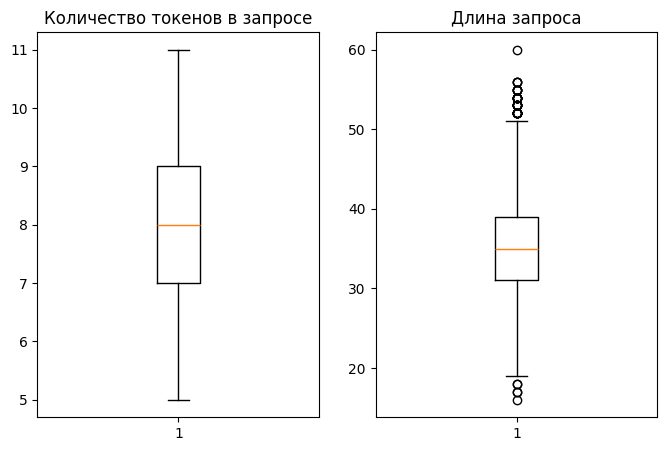

In [12]:
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title('Количество токенов в запросе')
plt.boxplot(df['n_tokens'])
plt.subplot(1,2,2)
plt.title('Длина запроса')
plt.boxplot(df['n_char']);

In [13]:
tag_distribution = df[['tag_item', 'tag_feat', 'tag_event']].agg('sum')
tag_distribution

,0
tag_item,655
tag_feat,917
tag_event,441


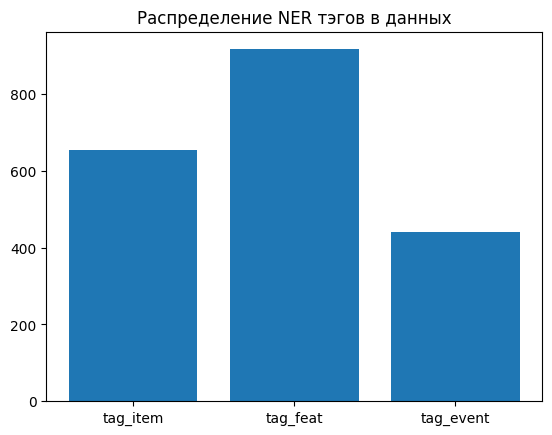

In [14]:
plt.bar(tag_distribution.index, tag_distribution)
plt.title('Распределение NER тэгов в данных');

In [39]:
unique_tags = sorted({t for row in df["ner_tags"] for t in row})
unique_tags.remove("O")
unique_tags = ["O"] + unique_tags

In [40]:
label2id = {lbl: i for i, lbl in enumerate(unique_tags)}
id2label = {i: lbl for lbl, i in label2id.items()}

In [46]:
df["tags"] = df["ner_tags"].apply(lambda row: [label2id[t] for t in row])
df

,tokens,ner_tags,request_type,n_char,n_tokens,tag_item,tag_feat,tag_event,tags
0,"[Хочу, такую, же, бермуды, ,, подскажите, где,...","[O, O, O, B-ITEM, O, O, O, O]",request_item,37,8,1,0,0,"[0, 0, 0, 3, 0, 0, 0, 0]"
1,"[Скиньте, ссылку, на, красный, свитер]","[O, O, O, B-FEAT, B-ITEM]",request_item,28,5,1,1,0,"[0, 0, 0, 2, 3]"
2,"[Ищу, белый, лонгслив, как, у, вас, ,, можно, ...","[O, B-FEAT, B-ITEM, O, O, O, O, O, O]",request_item,35,9,1,1,0,"[0, 2, 3, 0, 0, 0, 0, 0, 0]"
3,"[Можно, артикул, на, черный, плащ, ?]","[O, O, O, B-FEAT, B-ITEM, O]",request_item,25,6,1,1,0,"[0, 0, 0, 2, 3, 0]"
4,"[Хочу, такую, же, жилет, ,, подскажите, где, в...","[O, O, O, B-ITEM, O, O, O, O]",request_item,35,8,1,0,0,"[0, 0, 0, 3, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...
894,"[Подскажите, образы, для, фитнеса, ,, люблю, с...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set,44,8,0,1,2,"[0, 0, 1, 4, 0, 0, 2, 0]"
895,"[Подскажите, образы, для, фитнеса, ,, люблю, л...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set,46,8,0,1,2,"[0, 0, 1, 4, 0, 0, 2, 0]"
897,"[Хочу, луки, на, выпускной, ,, особенно, с, бе...","[O, O, B-EVENT, I-EVENT, O, O, O, B-FEAT, B-ITEM]",request_set,42,9,1,1,2,"[0, 0, 1, 4, 0, 0, 0, 2, 3]"
898,"[Подскажите, образы, для, свадьбы, ,, люблю, л...","[O, O, B-EVENT, I-EVENT, O, O, B-FEAT, O]",request_set,46,8,0,1,2,"[0, 0, 1, 4, 0, 0, 2, 0]"


In [50]:
features = Features({
    "tokens": Sequence(Value("string")),
    "tags": Sequence(ClassLabel(num_classes=len(unique_tags), names=unique_tags))
})

hf_all = Dataset.from_pandas(df[['tokens','tags']], features=features, preserve_index=False)
ds = hf_all.train_test_split(test_size=0.2, seed=1)
ds

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 608
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 153
    })
})

In [52]:
save_dir = '/content/drive/MyDrive/Colab Notebooks/dl/proj_fashion_ner/fashion_dataset_dict'
ds.save_to_disk(save_dir)

with open(f"{save_dir}/label_maps.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)

Saving the dataset (0/1 shards):   0%|          | 0/608 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/153 [00:00<?, ? examples/s]